In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
train_data=pd.read_csv('train.csv')
test_data=pd.read_csv('test.csv')

In [3]:
data=pd.concat([train_data,test_data])
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,12700.000000,12707.000000,12681.000000,12664.000000,12686.000000,12702.000000
mean,28.771969,222.897852,451.961675,174.906033,308.476904,306.789482
std,14.387261,647.596664,1584.370747,590.558690,1130.279641,1180.097223
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,49.000000,77.000000,29.000000,57.000000,42.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [5]:
len(data)

12970

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12682 non-null  object 
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  object 
 4   Destination   12696 non-null  object 
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  object 
 13  Transported   8693 non-null   object 
dtypes: float64(6), object(8)
memory usage: 1.5+ MB


In [7]:
data['Transported'].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

In [8]:
len(data.dropna())

6606

<Axes: >

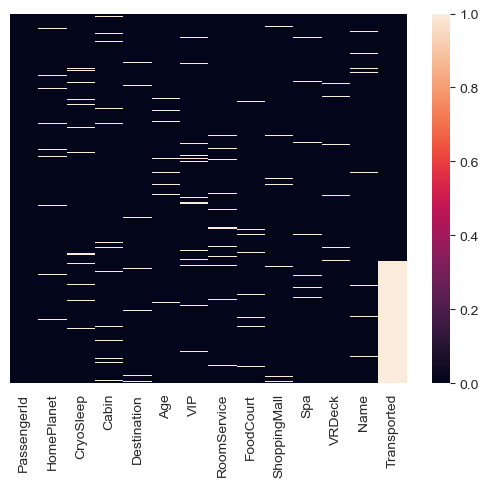

In [9]:
sns.heatmap(data.isnull(),yticklabels=False,cmap='rocket')

In [10]:
data['Family']=data['PassengerId'].apply(lambda x:x.split('_')[0])

In [11]:
data.select_dtypes(include='number').columns

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='object')

In [12]:
print(data['HomePlanet'].unique())
print(data['Destination'].unique())

['Europa' 'Earth' 'Mars' nan]
['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' nan]


In [13]:
data['Spend'] = data[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)

In [14]:
def fill_zero(x):
    if pd.isnull(x.iloc[1]):
        if x.iloc[0]==True:
            return 0
    else:
        return x.iloc[1]
def fill_cryo(x):
    if pd.isnull(x.iloc[0]):
        if x.iloc[1]==0:
            return True
        else:
            return False
    return x.iloc[0]

In [15]:
data['CryoSleep']=data[['CryoSleep','Spend']].apply(fill_cryo,axis=1)
data['CryoSleep']=data[['CryoSleep','FoodCourt']].apply(fill_cryo,axis=1)
data['CryoSleep']=data[['CryoSleep','RoomService']].apply(fill_cryo,axis=1)
data['VIP'].bfill(inplace=True)

In [16]:
def fill_home(x):
    if pd.isna(x.iloc[1]):
        temp_df=data[data['Family']==x.iloc[0]]
        if len(temp_df['HomePlanet'].dropna().unique())==0:
            return np.nan
        return temp_df['HomePlanet'].dropna().unique()[0]
    return x.iloc[1]
def fill_destination(x):
    if pd.isna(x.iloc[1]):
        temp_df=data[data['Family']==x.iloc[0]]
        if len(temp_df['Destination'].dropna().unique())==0:
            return np.nan
        return temp_df['Destination'].dropna().unique()[0]
    return x.iloc[1]

In [17]:
data['HomePlanet']=data[['Family','HomePlanet']].apply(fill_home,axis=1)
data['HomePlanet'].bfill(inplace=True)
data['Destination']=data[['Family','Destination']].apply(fill_destination,axis=1)
data['Destination'].bfill(inplace=True)
for i in data.select_dtypes(include='number').columns:
    if i=='Transported':
        continue
    if i=='Age':
        data[i].fillna(data.groupby(['VIP','HomePlanet'])[i].transform('mean'),inplace=True)
        continue
    data[i]=data[['CryoSleep',i]].apply(fill_zero,axis=1)
    data[i].fillna(data.groupby(['VIP','HomePlanet'])[i].transform('mean'),inplace=True)

In [18]:
data.groupby(['VIP','HomePlanet'])['Age'].mean()

VIP    HomePlanet
False  Earth         25.991118
       Europa        34.091185
       Mars          29.231510
True   Earth         47.000000
       Europa        37.223464
       Mars          34.967391
Name: Age, dtype: float64

In [19]:
def side(s):
    if pd.isnull(s):
        return s
    else:
        return s[-1]

In [20]:
def cabin(s):
    if pd.isnull(s):
        return s
    else:
        return s[0]

In [21]:
data['Deck']=data['Cabin'].apply(cabin)
data['Cabin']=data['Cabin'].apply(side)

In [22]:
data['Deck'].bfill(inplace=True)
data['Cabin'].bfill(inplace=True)
data.drop(['Name'],inplace=True,axis=1)

<Axes: >

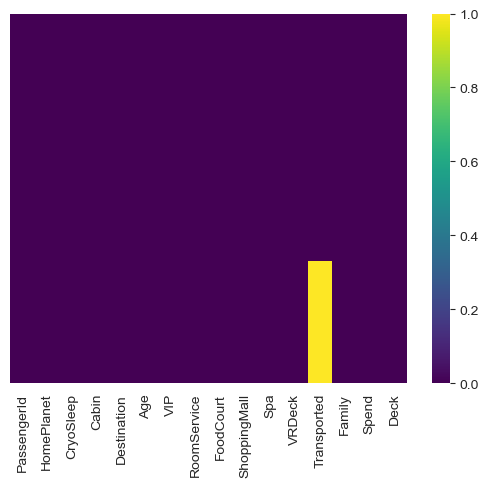

In [23]:
sns.heatmap(data.isnull(),yticklabels=False,cmap='viridis')

In [24]:
data.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported', 'Family', 'Spend', 'Deck'],
      dtype='object')

In [25]:
data.drop(['Spend'],axis=1,inplace=True)
data.drop(['Family'],axis=1,inplace=True)
data.to_csv('clean.csv')

In [26]:
train=data[~pd.isnull(data['Transported'])]
test=data[pd.isnull(data['Transported'])]

In [27]:
X=pd.get_dummies(data=train.drop(['PassengerId','Transported'],axis=1),drop_first=True)
y=pd.Series(train['Transported']*1.0,name='Transported',dtype=np.float16)
X_test=pd.get_dummies(data=test.drop(['PassengerId'],axis=1),drop_first=True)
y_test=pd.Series(test['Transported']*1.0,name='Transported',dtype=np.float16)

In [29]:
X=pd.DataFrame(data=StandardScaler().fit_transform(X),columns=X.columns)
X_test=pd.DataFrame(data=StandardScaler().fit_transform(X_test),columns=X_test.columns)

In [30]:
for i in X.columns:
    X[i]=X[i]*1.0
    X_test[i]=X_test[i]*1.0

In [31]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20)

In [38]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

In [43]:
models=[LogisticRegression(),SVC(),RandomForestClassifier(),GradientBoostingClassifier(),XGBClassifier(verbose = 0)]

In [46]:
for model in models:
    print(f"Model CLassification report for : {model}".split("(")[0])
    classifier=model.fit(X_train,y_train)
    val_preds=classifier.predict(X_val)
    print(classification_report(y_val,val_preds))

Model CLassification report for : LogisticRegression
              precision    recall  f1-score   support

         0.0       0.77      0.79      0.78       814
         1.0       0.81      0.79      0.80       925

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739

Model CLassification report for : SVC
              precision    recall  f1-score   support

         0.0       0.77      0.81      0.79       814
         1.0       0.83      0.79      0.81       925

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739

Model CLassification report for : RandomForestClassifier
              precision    recall  f1-score   support

         0.0       0.76      0.84      0.80       814
         1.0       0.84      0.77      0.80       925

    accuracy                      